# Import

In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

In [2]:
import torch
import numpy as np
import mmap

In [3]:
import pandas as pd
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torchvision import transforms
import concurrent.futures
from PIL import Image
import shutil

In [4]:
import albumentations as albu


In [5]:
from torch.utils.data import Dataset
from typing import Union,List,Tuple
import pathlib
from timeit import default_timer as timer
from torch.utils.data import DataLoader
import h5py
from tqdm import tqdm
import torchvision
import matplotlib.pyplot as plt
from sklearn.utils import shuffle
import time
from torch.utils.tensorboard import SummaryWriter

In [6]:
# mlfmow library
import mlflow
import mlflow.pytorch


# MLflow run

In [7]:
from mlflow.exceptions import MlflowException
import datetime

# End MLflow run
mlflow.end_run()

# Function to generate a unique experiment name
def generate_experiment_name():
    return f"experiment-{datetime.datetime.now().strftime('%Y-%m-%d_%H-%M-%S')}"

# Function to create and set a new experiment
def set_experiment(experiment_name):
    try:
        experiment = mlflow.get_experiment_by_name(experiment_name)
        if experiment is None:
            mlflow.create_experiment(experiment_name)
            experiment = mlflow.get_experiment_by_name(experiment_name)
        mlflow.set_experiment(experiment_name)
    except MlflowException as e:
        print(f"Error setting experiment: {e}")
        
        
# Generate a unique experiment name and set the experiment
experiment_name = generate_experiment_name()
set_experiment(experiment_name)

# Verify the experiment is set correctly
print(f"Set experiment '{experiment_name}'")


# Start an MLflow run
mlflow.start_run(run_name=f"training-{datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

# Unique runs directory
runs_dir = os.path.join("runs", experiment_name, datetime.datetime.now().strftime('%Y-%m-%d_%H-%M-%S'))



Set experiment 'experiment-2024-07-31_17-41-30'


In [8]:
#Put the device on GPU if possible to train the model faster than with CPU

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Log device information
mlflow.log_param("device", "cuda:0" if torch.cuda.is_available() else "cpu")

batch_size = 32
period_size = 8
weight_decay = 0.1
epsilon = 10**(-8)
epochs_num = 8
learning_rate = 10**(-3)
n_channel = 1
class_num = 3
dropout_rate = 0.5

# Define your source and destination directories
label_dir = "D:/Donnees_pour_segmentation_RDN/data/deux/Label1"
input_dir = "D:/Donnees_pour_segmentation_RDN/data/deux/Unseg1"
new_label_dir = "D:/Donnees_pour_segmentation_RDN/data/deux_mini/Label"
new_input_dir = "D:/Donnees_pour_segmentation_RDN/data/deux_mini/Unseg"

stride = 32
train_size = 0.7

output = 128   #patch size TO DO

# Log parameters
mlflow.log_param("batch_size", batch_size)
mlflow.log_param("period_size", period_size)
mlflow.log_param("weight_decay", weight_decay)
mlflow.log_param("epsilon", epsilon)
mlflow.log_param("epochs_num", epochs_num)
mlflow.log_param("learning_rate", learning_rate)
mlflow.log_param("n_channel", n_channel)
mlflow.log_param("class_num", class_num)
mlflow.log_param("label_dir", label_dir)
mlflow.log_param("input_dir", input_dir)
mlflow.log_param("runs_dir", runs_dir)
mlflow.log_param("stride", stride)
mlflow.log_param("train_size", train_size)
mlflow.log_param("output", output)
mlflow.log_param("dropout_rate", dropout_rate)

# Initialize TensorBoard writer
writer = SummaryWriter(runs_dir)

# Select files

In [9]:
# Ensure the new directories exist
os.makedirs(new_label_dir, exist_ok=True)
os.makedirs(new_input_dir, exist_ok=True)

# Function to empty the destination directories
def empty_directory(directory):
    for filename in os.listdir(directory):
        file_path = os.path.join(directory, filename)
        if os.path.isfile(file_path) or os.path.islink(file_path):
            os.unlink(file_path)
        elif os.path.isdir(file_path):
            shutil.rmtree(file_path)

# Function to copy files
def copy_files(file_paths, destination_dir):
    for file_path in file_paths:
        shutil.copy(file_path, destination_dir)

# Function to get the number of digits in the file names
def get_num_digits(directory):
    files = [f for f in os.listdir(directory) if f.endswith('.tif')]
    if not files:
        raise ValueError("No .tif files found in the directory")
    num_digits = len(files[0].split('_')[-1].split('.')[0])
    return num_digits

# Function to get image files by index range
def get_image_files_by_index(directory, start_index, end_index):
    num_digits = get_num_digits(directory)
    image_files = []
    for idx in range(start_index, end_index + 1):
        file_name = f"{directory}/deux_{idx:0{num_digits}}.tif"
        if os.path.exists(file_name):
            image_files.append(file_name)
        else:
            print(f"File not found: {file_name}")
    return image_files

# Empty the destination directories
empty_directory(new_label_dir)
empty_directory(new_input_dir)

# Get the list of image files
label_files = get_image_files_by_index(label_dir, start_index=800, end_index=830)
input_files = get_image_files_by_index(input_dir, start_index=800, end_index=830)

# Copy the files to the new directories
copy_files(label_files, new_label_dir)
copy_files(input_files, new_input_dir)

print("Files copied successfully!")


Files copied successfully!


# Dataset

In [10]:
def load_patches(patches):

    if isinstance(patches, str):
        return np.array(pd.read_csv(patches, header=0)).tolist()
    else:
        return patches

# HDF52D dataset class
class HDF52D(Dataset):
    def __init__(self, patches, input_list, label_list, transform=None):
        self.patches = patches
        self.input_list = input_list
        self.label_list = label_list
        self.transform = transform
        self.mode = 'train'

    def __getitem__(self, idx):
        p = self.patches[self.mode][idx]
        image = self.input_list[p[0]][int(p[1]):int(p[1]) + int(p[3]), int(p[2]):int(p[2]) + int(p[4])]
        mask = self.label_list[p[0]][int(p[1]):int(p[1]) + int(p[3]), int(p[2]):int(p[2]) + int(p[4])]
        sample = {'image': image, 'mask': mask}

        print(f"Original Image shape: {image.shape}, Original Mask shape: {mask.shape}")  # Debugging statement

        if self.transform is not None:
            sample = self.transform(sample)

        print(f"Transformed Image shape: {sample['image'].shape}, Transformed Mask shape: {sample['mask'].shape}")  # Debugging statement
        
        return sample

    def __len__(self):
        return len(self.patches[self.mode])

    def train(self):
        self.mode = 'train'

    def val(self):
        self.mode = 'val'


In [11]:
#print("MLflow tracking URI:", mlflow.get_tracking_uri())

# Dataprocess

In [12]:
def create_one_hot(mask, num_classes=3):
    one_hot_mask = torch.zeros([mask.shape[0], num_classes, mask.shape[1], mask.shape[2]], dtype=torch.float32)
    if mask.is_cuda:
        one_hot_mask = one_hot_mask.cuda()
    one_hot_mask = one_hot_mask.scatter(1, mask.long().data.unsqueeze(1), 1.0)
    #print(f"One-hot encoded mask unique values: {torch.unique(one_hot_mask)}")
    return one_hot_mask

class AdjustMask(object):
    def __init__(self, class_num=3):
        self.class_num = class_num

    def __call__(self, sample):
        mask = sample['mask']
        sample['mask'] = self.adjust_mask(mask, self.class_num)
        return sample

    def adjust_mask(self, mask, class_num):
        interval = int(256.0 / class_num)
        new_mask = np.zeros((mask.shape[0], mask.shape[1]), dtype=np.longlong)
        for i in range(class_num):
            if i <= class_num - 2:
                new_mask[(mask >= i * interval) & (mask < (i + 1) * interval)] = i
            else:
                new_mask[i * interval <= mask] = i
        return new_mask

class ToTensor(object):
    def __call__(self, sample):
        image, mask = sample['image'], sample['mask']
        if len(image.shape) == 2:  # Grayscale image
            image = np.expand_dims(image, axis=0)
        else:  # Multichannel image
            image = image.transpose((2, 0, 1))
        sample['image'] = torch.from_numpy(image)
        sample['mask'] = torch.from_numpy(mask)
        return sample

class Normalize(object):
    def __init__(self, max=255.0, min=0.0, tg_max=1.0, tg_min=0.0):
        self.max = max
        self.min = min
        self.tg_max = tg_max
        self.tg_min = tg_min

    def __call__(self, sample):
        image = sample['image'].astype('float32')
        image = self.tg_min + ((image - self.min) * (self.tg_max - self.tg_min)) / (self.max - self.min)
        sample['image'] = image
        return sample


# Class to perform data augmentation
class Augmentation(object):
    def __init__(self):
        self.augmentation_pipeline = albu.Compose([
            albu.OneOf([
                albu.HorizontalFlip(p=1),
                albu.VerticalFlip(p=1),
                albu.Compose([
                    albu.HorizontalFlip(p=1),
                    albu.VerticalFlip(p=1),
                ])
            ], p=0.75),
            albu.RandomRotate90(p=1),
        ])

    def __call__(self, sample):
        image = sample['image']
        mask = sample['mask']
        
        # Apply the augmentation pipeline without resizing
        augmented = self.augmentation_pipeline(image=image, mask=mask)
        sample['image'] = augmented['image']
        sample['mask'] = augmented['mask']

        return sample



# Generate Patches

In [13]:
#get_minimum_dirt_patches create a subset of initial patches focusing on patches containing dirt (depending on dirt_rate)
# Input :
# dirt_choose_threshold: A threshold value for the dirt ratio to determine whether a patch is considered as a dirt patch.
# dirt_rate: The desired proportion of dirt patches in the selected subset.
# patches: A NumPy array containing information about patches (name, top, left, height, width).
# ratios: A NumPy array containing ratios for each patch (class ratios).
#
# Output :
# returns a subset of initial patches
def get_minimum_dirt_patches(dirt_choose_threshold: float, dirt_rate: float, patches: np.array, ratios: np.array):
    # Get ratios
    ratios = np.array(ratios)
    # Get index that would sort ratios by decreasing order
    ratios_idx = np.argsort(-ratios, axis=0)

    # Get the second column of ratio_idx which is the dirt index sorted by decreasing order
    dirt_idx = ratios_idx[:, 1]

    # Get only the patches that dirt ratio is > dirt_choose_threshold
    last_idx = 0
    for i in range(dirt_idx.shape[0]):
        dirt_ratio = ratios[dirt_idx[i], 1]
        if dirt_ratio < dirt_choose_threshold:
            last_idx = i
            break

    # Indexes of wanted dirt_patches
    dirt_patches_idx = dirt_idx[0:last_idx]
    # Indexes of other patches
    rest_idx = dirt_idx[last_idx:-1]

    if not (dirt_rate == 0):
        rest_num = round(((last_idx - 1) / dirt_rate) * (1 - dirt_rate))
        if rest_num > rest_idx.shape[0]:
            rest_num = rest_idx.shape[0]
    else:
        rest_num = rest_idx.shape[0]

    # Getting picking other patches
    random_idx = np.random.choice(rest_idx.shape[0], size=rest_num, replace=False)
    non_dirt_patches_idx = rest_idx[random_idx]

    # Getting the final patches
    patches_idx = np.concatenate((dirt_patches_idx, non_dirt_patches_idx), axis=0)
    
    # Ensure indices are within the valid range
    valid_patches_idx = [idx for idx in patches_idx if idx < len(patches)]
    if len(valid_patches_idx) != len(patches_idx):
        print(f"Warning: Some indices were out of bounds and have been removed.")

    new_patches = np.asarray(patches)[valid_patches_idx, :].tolist()

    new_patches = shuffle(new_patches)
    new_patches = [[name, int(top), int(left), int(h), int(w)] for [name, top, left, h, w] in new_patches]

    print(f"Length of dirt_patches_idx: {len(dirt_patches_idx)}")
    print(f"Length of non_dirt_patches_idx: {len(non_dirt_patches_idx)}")
    print(f"Length of patches_idx: {len(patches_idx)}")
    print(f"Length of patches: {len(patches)}")
    print(f"Max index in patches_idx: {max(patches_idx)}")
    print(f"Min index in patches_idx: {min(patches_idx)}")
    print(f"Valid patches indices: {all(idx < len(patches) for idx in patches_idx)}")
    
    return new_patches


#get_dirt_bone_patches create a subset of initial patches focusing on patches containing air (depending on air_rate)
# Input :
# patches: A NumPy array containing information about patches (name, top, left, height, width).
# ratios: A NumPy array containing ratios for each patch (class ratios).
# air_rate: The desired proportion of air patches in the selected subset.
#
# Output :
# returns a list of extracted patches based on the specified conditions and an index representing the length of this list
def get_dirt_bone_patches(patches: np.array, ratios: np.array, air_rate: float):
    # Get ratios 
    ratios = np.array(ratios)
    # Get indices that would sort ratios by decreasing order
    ratios_idx = np.argsort(-ratios, axis=0) 

    # Get the second column of ratio_idx which is the dirt index sorted by decreasing order
    dirt_idx = ratios_idx[:, 1]
    # Get patches 
    patches = np.asarray(patches)

    # Ensure indices are within the valid range
    valid_dirt_idx = [idx for idx in dirt_idx if idx < len(patches)]
    if len(valid_dirt_idx) != len(dirt_idx):
        print(f"Warning: Some dirt indices were out of bounds and have been removed.")

    # Get ratios and patches sorted by decreasing dirt ratios 
    ratios_sort = ratios[valid_dirt_idx, :]
    patches_sort = patches[valid_dirt_idx, :]
    
    dirt_patches = []
    bone_patches = []
    
    while (len(dirt_patches) < 128 or len(bone_patches) < 128) and air_rate < 1:  # in the case that we have not enough patches 
        dirt_patches = []
        bone_patches = []
        # Get patches that contain significant differences between dirt and bone ratios (>0.1)
        for idx in range(ratios_sort.shape[0]):
            if (ratios_sort[idx, 0] < air_rate):
                if (ratios_sort[idx, 1] - ratios_sort[idx, 2] > 0.15):
                    dirt_patches.append(patches_sort[idx, :].tolist())
                elif (ratios_sort[idx, 2] - ratios_sort[idx, 1] > 0.15):
                    bone_patches.append(patches_sort[idx, :].tolist())
            else:
                pass
        air_rate += 0.1

    dirt_len = len(dirt_patches)
    bone_len = len(bone_patches)

    bone_index = [1 for i in range(bone_len)]
    dirt_index = [0 for i in range(dirt_len)]
    
    dirt_patches = shuffle(dirt_patches)
    bone_patches = shuffle(bone_patches)

    print(f"There are {bone_len} bone and {dirt_len} dirt patches in the training data...")

    end_idx = dirt_len if dirt_len < bone_len else bone_len
    # Get the same quantity of dirt and bone patches
    new_patches = []
    for patch in dirt_patches:
        new_patches.append(patch)
    for patch in bone_patches:
        new_patches.append(patch)

    d_index = len(new_patches)
    
    return new_patches, d_index


#slide_windows generate a list of patches based on a sliding window approach over an input image or data.
# Input :
# name : A string representing the name or identifier for the image or data.
# shape : A tuple representing the shape (height, width) of the input image or data.
# output_size (int): An integer or tuple representing the size of the output patches. Default is set to (128, 128).
# stride (int): An integer or tuple representing the stride of the sliding window. Default is set to 32.
#
# Output :
#  A list of lists, where each inner list contains information about a patch
def slide_windows(name, shape, output_size=output, stride=32):
    output_sizes = (output_size, output_size)
    strides = (stride, stride)

    patches_list = []
    idx = 0
    while idx * strides[0] + output_sizes[0] <= shape[0]:
        top = idx * strides[0]
        j = 0
        while j * strides[1] + output_sizes[1] <= shape[1]:
            left = j * strides[1]
            patches_list.append([name, top, left,output_sizes[0], output_sizes[1]])
            j += 1

        if j * strides[1] < shape[1]:
            left = shape[1] - output_sizes[1]
            patches_list.append([name, top, left, output_sizes[0], output_sizes[1]])
        idx += 1

    if idx * strides[0] < shape[0]:
        top = shape[0] - output_sizes[0]
        j = 0
        while j * strides[1] + output_sizes[1] <= shape[1]:
            left = j * strides[1]
            patches_list.append([name, top, left, output_sizes[0], output_sizes[1]])
            j += 1

        if j * strides[1] < shape[1]:
            left = shape[1] - output_sizes[1]
            patches_list.append([name, top, left, output_sizes[0], output_sizes[1]])
    return patches_list


#get_patches generate patches from a collection of images
# Input :
# data: A dictionary where keys represent image names, and values are the corresponding images (arrays).
# stride: An integer representing the stride of the sliding window. Default is set to 32.
# output_size: An integer representing the size of the output patches. Default is set to 256.
#
# Output :
#  A list of lists, where each inner list contains information about a patch
def get_patches(data, stride: int = 32, output_size = output):
    # Start a nested MLflow run for this function
    with mlflow.start_run(nested=True, run_name="get_patches"):
        # Log parameters
        mlflow.log_param("get_patches_stride", stride)
        mlflow.log_param("get_patches_output_size", output_size)
        
        patches = []
        # Iterate for each image
        for name in (data.keys()):
            shape = data[name].shape
            patches += slide_windows(name, shape, output_size=output_size, stride=stride)
        shuffle(patches)
            
        # Log the number of patches generated
        mlflow.log_metric("num_patches_generated", len(patches))        
        
        return patches


#generate_ratios calculates ratios for each patch based on the pixel values in the corresponding labeled masks
# Input :
# patches: A list of lists, where each inner list contains information about a patch (name, top, left, height, width)
# class_num: An integer representing the number of classes in the labeled masks. Default is set to 3.
#
# Output:
# A list of lists, where each inner list contains class ratios for a patch.
def generate_ratios(patches, class_num=3):
    # Start a nested MLflow run for this function
    with mlflow.start_run(nested=True, run_name="generate_ratios"):
        # Log parameter
        mlflow.log_param("generate_ratios_class_num", class_num)
        
        # initialize ratios to 0
        ratios = []
        for i in range(len(patches)):
            mask = plt.imread(new_label_dir + "/" + patches[0][i])[patches[1][i]: patches[1][i] + patches[3][i], patches[2][i]: patches[2][i] + patches[4][i]]
            mask = adjustMask(mask, class_num)
            size = 1.0
            for idx in range(len(mask.shape)):
                size *= mask.shape[idx]

            # Get ratio for the patch
            ratio = []
            for idx in range(class_num):
                ratio.append(np.sum(mask == idx) / size) 

            ratios.append(ratio)
        
        # Log the number of ratios generated
        mlflow.log_metric("num_ratios_generated", len(ratios))    
        
        return ratios


# UNet-parts

In [14]:
class DoubleConv(nn.Module):
    """(convolution => [BN] => ReLU) * 2"""

    def __init__(self, in_channels, out_channels, dropout_rate):
        super(DoubleConv, self).__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate),  # Add dropout here
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate)  # Add dropout here
        )

    def forward(self, x):
        return self.double_conv(x)


class Down(nn.Module):
    """Downscaling with maxpool then double conv"""

    def __init__(self, in_channels, out_channels, dropout_rate):
        super(Down, self).__init__()
        self.maxpool_conv = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channels, out_channels, dropout_rate)
        )

    def forward(self, x):
        return self.maxpool_conv(x)


class Up(nn.Module):
    """Upscaling then double conv"""

    def __init__(self, in_channels, out_channels, dropout_rate, bilinear=True):
        super(Up, self).__init__()

        # if bilinear, use the normal convolutions to reduce the number of channels
        if bilinear:
            self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        else:
            self.up = nn.ConvTranspose2d(in_channels // 2, in_channels // 2, kernel_size=2, stride=2)

        self.conv = DoubleConv(in_channels, out_channels, dropout_rate)

    def forward(self, x1, x2):
        x1 = self.up(x1)
        # input is CHW
        diffY = torch.tensor([x2.size()[2] - x1.size()[2]])
        diffX = torch.tensor([x2.size()[3] - x1.size()[3]])

        x1 = F.pad(x1, [diffX // 2, diffX - diffX // 2,
                        diffY // 2, diffY - diffY // 2])
        # if you have padding issues, see
        # https://github.com/HaiyongJiang/U-Net-Pytorch-Unstructured-Buggy/commit/0e854509c2cea854e247a9c615f175f76fbb2e3a
        # https://github.com/xiaopeng-liao/Pytorch-UNet/commit/8ebac70e633bac59fc22bb5195e513d5832fb3bd
        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)


class OutConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(OutConv, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x):
        return self.conv(x)


# UNet Light RDN

In [15]:
class UNet_Light_RDN(nn.Module):
    def __init__(self, n_channels, n_classes, dropout_rate, bilinear=True):
        super(UNet_Light_RDN, self).__init__()
        self.n_channels = n_channels
        self.n_classes = n_classes
        self.bilinear = bilinear

        self.inc = DoubleConv(1, 32, dropout_rate)
        self.down1 = Down(32, 64, dropout_rate)
        self.down2 = Down(64, 128, dropout_rate)
        self.down3 = Down(128, 256, dropout_rate)
        self.down4 = Down(256, 256, dropout_rate)
        self.up1 = Up(512, 128, dropout_rate, bilinear)
        self.up2 = Up(256, 64, dropout_rate, bilinear)
        self.up3 = Up(128, 32, dropout_rate, bilinear)
        self.up4 = Up(64, 32, dropout_rate, bilinear)
        self.outc = OutConv(32, n_classes)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)
        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)
        logits = self.outc(x)
        return logits

In [16]:
# create train transform
train_transform = transforms.Compose([Augmentation(), #config['output_size']
                                                    AdjustMask(class_num=class_num),
                                                    Normalize(max=255, min=0),
                                                    ToTensor()])

val_transform = transforms.Compose([AdjustMask(class_num=class_num),
                                                    Normalize(max=255, min=0),
                                                    ToTensor()])
# Define AdjustMask class
class AdjustMask(object):
    def __init__(self, class_num=3):
        self.class_num = class_num

    def __call__(self, sample):
        mask = sample['mask']
        sample['mask'] = self.adjust_mask(mask, self.class_num)
        return sample

    def adjust_mask(self, mask, class_num):
        interval = int(256.0 / class_num)
        new_mask = np.zeros((mask.shape[0], mask.shape[1]), dtype=np.longlong)
        for i in range(class_num):
            if i <= class_num - 2:
                new_mask[(mask >= i * interval) & (mask < (i + 1) * interval)] = i
            else:
                new_mask[i * interval <= mask] = i
        return new_mask

# Function to remove singular patches
def remove_singular_patches(patches, batch_size):
    num_patches = len(patches)
    num_singular_patches = num_patches % batch_size
    if num_singular_patches > 0:
        patches = patches[:-num_singular_patches]
    print(f"Removed {num_singular_patches} singular patches.")  # Debug print statement
    return patches

# Ensure patches are valid
def get_valid_patches(data, stride, output_size, batch_size):
    patches = get_patches(data, stride, output_size)
    patches = remove_singular_patches(patches, batch_size)
    if not patches:
        raise ValueError("Not enough patches to form a single batch. Increase the number of images or reduce the batch size.")
    return patches

# Function to filter patches by air ratio
def filter_patches_by_air_ratio(patches, ratios, air_threshold):
    filtered_patches = [patch for patch, ratio in zip(patches, ratios) if ratio[0] < air_threshold]
    print(f"Filtered {len(filtered_patches)} patches with air ratio below {air_threshold}")
    return filtered_patches

# Function to generate ratios for the patches
def generate_ratios(patches, class_num=3):
    adjust_mask_instance = AdjustMask(class_num=class_num)
    with mlflow.start_run(nested=True, run_name="generate_ratios"):
        mlflow.log_param("generate_ratios_class_num", class_num)
        ratios = []
        for patch in patches:
            filename, top, left, height, width = patch
            mask = plt.imread(os.path.join(new_label_dir, filename))
            mask = mask[int(top): int(top) + int(height), int(left): int(left) + int(width)]
            mask = adjust_mask_instance.adjust_mask(mask, class_num)
            size = mask.size
            ratio = [np.sum(mask == idx) / size for idx in range(class_num)]
            ratios.append(ratio)
        mlflow.log_metric("num_ratios_generated", len(ratios))
        return ratios

def create_dataloaders(train_patches_df, val_patches_df, input_list, label_list, batch_size, train_transform, val_transform):
    train_dataset = HDF52D(train_patches_df.values.tolist(), input_list, label_list, transform=train_transform)
    val_dataset = HDF52D(val_patches_df.values.tolist(), input_list, label_list, transform=val_transform)

    train_data_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
    val_data_loader = DataLoader(dataset=val_dataset, batch_size=batch_size, shuffle=False, num_workers=4)

    return train_data_loader, val_data_loader

# Function to split the dataset into training and validation sets
def split_dataset(data, train_size):
    keys = list(data.keys())
    np.random.shuffle(keys)  # Shuffle the keys to ensure random splitting
    split_idx = int(len(keys) * train_size)
    train_keys = keys[:split_idx]
    val_keys = keys[split_idx:]
    train_data = {key: data[key] for key in train_keys}
    val_data = {key: data[key] for key in val_keys}
    return train_data, val_data



# Parameters

In [17]:

    
class HDF52D(Dataset):
    def __init__(self, patches, input_list, label_list, transform=None):
        self.patches = patches
        self.input_list = input_list
        self.label_list = label_list
        self.transform = transform
        self.mode = 'train'

    def __getitem__(self, idx):
        p = self.patches[idx]
        filename, top, left, height, width = p
        top, left, height, width = map(int, [top, left, height, width])
        image = self.input_list[filename][top:top + height, left:left + width]
        mask = self.label_list[filename][top:top + height, left:left + width]
        sample = {'image': image, 'mask': mask}

        if self.transform is not None:
            sample = self.transform(sample)

        return sample

    def __len__(self):
        return len(self.patches)

    def train(self):
        self.mode = 'train'

    def val(self):
        self.mode = 'val'



# Parameters
name_list = os.listdir(new_label_dir)
label_list = {name: plt.imread(os.path.join(new_label_dir, name)) for name in name_list}
input_list = {name: plt.imread(os.path.join(new_input_dir, name)) for name in name_list}

# Split the dataset into training and validation sets
train_input_list, val_input_list = split_dataset(input_list, train_size)
train_label_list, val_label_list = split_dataset(label_list, train_size)

air_threshold = 0.8  # Air threshold for filtering patches

# Step 1: Divide images into patches
train_patches = get_valid_patches(train_input_list, stride=stride, output_size=output, batch_size=batch_size)
val_patches = get_valid_patches(val_input_list, stride=stride, output_size=output, batch_size=batch_size)

# Step 2: Generate ratios for the patches
train_ratios = generate_ratios(train_patches, class_num=class_num)
val_ratios = generate_ratios(val_patches, class_num=class_num)

# Step 3: Filter patches based on air ratio
filtered_train_patches = filter_patches_by_air_ratio(train_patches, train_ratios, air_threshold)
filtered_val_patches = filter_patches_by_air_ratio(val_patches, val_ratios, air_threshold)

# Print the filtering results
print(f"Total patches: {len(train_patches)}")
print(f"Filtered train patches: {len(filtered_train_patches)}")
print(f"Filtered val patches: {len(filtered_val_patches)}")

# Remove singular patches from filtered patches
filtered_train_patches = remove_singular_patches(filtered_train_patches, batch_size)
filtered_val_patches = remove_singular_patches(filtered_val_patches, batch_size)

# Convert filtered patches back to DataFrame
filtered_train_patches_df = pd.DataFrame(filtered_train_patches, columns=["filename", "top", "left", "height", "width"])
filtered_val_patches_df = pd.DataFrame(filtered_val_patches, columns=["filename", "top", "left", "height", "width"])

# Create DataLoader objects
train_data_loader, val_data_loader = create_dataloaders(
    filtered_train_patches_df, filtered_val_patches_df,
    train_input_list, train_label_list, batch_size, train_transform, val_transform
)

# Debug: Check data loader
print(f"Train loader batches: {len(train_data_loader)}")
print(f"Validation loader batches: {len(val_data_loader)}")

# Log the number of patches generated
mlflow.log_metric("num_train_patches", len(filtered_train_patches))
mlflow.log_metric("num_val_patches", len(filtered_val_patches))

# Calculate and log the mean ratios for each class
ratios_df = pd.DataFrame(train_ratios)
mean_ratios = ratios_df.mean(axis=0)
mlflow.log_metric("mean_air_ratio", mean_ratios[0])
mlflow.log_metric("mean_bone_ratio", mean_ratios[1])
mlflow.log_metric("mean_dirt_ratio", mean_ratios[2])

print(f"Mean air ratio: {mean_ratios[0]}")
print(f"Mean bone ratio: {mean_ratios[1]}")
print(f"Mean dirt ratio: {mean_ratios[2]}")

Removed 20 singular patches.
Removed 8 singular patches.
Filtered 592 patches with air ratio below 0.8
Filtered 283 patches with air ratio below 0.8
Total patches: 736
Filtered train patches: 592
Filtered val patches: 283
Removed 16 singular patches.
Removed 27 singular patches.
Train loader batches: 18
Validation loader batches: 8
Mean air ratio: 0.6773485100787618
Mean bone ratio: 0.05575627865998641
Mean dirt ratio: 0.2668952112612517


# Debugging part

In [18]:
# Import necessary libraries
import random
import torch
import os
from torch.utils.data import Dataset, DataLoader

# Define the HDF52D class with added debugging statements
class HDF52D(Dataset):
    def __init__(self, train_patches, val_patches, train_transform=None, val_transform=None):
        self.patches = {'train': train_patches, 'val': val_patches}
        self.transforms = {'train': train_transform, 'val': val_transform}
        self.mode = 'train'

    def __getitem__(self, idx):
        p = self.patches[self.mode][idx]
        filename, top, left, height, width = p
        top, left, height, width = map(int, [top, left, height, width])
        image = input_list[filename][top:top + height, left:left + width]
        mask = label_list[filename][top:top + height, left:left + width]
        sample = {'image': image, 'mask': mask}

        if self.transforms[self.mode] is not None:
            sample = self.transforms[self.mode](sample)
        
        return sample

    def __len__(self):
        return len(self.patches[self.mode])

    def train(self):
        self.mode = 'train'

    def val(self):
        self.mode = 'val'


def debug_data_loader(data_loader, num_batches=3):
    """Debug DataLoader by loading a few batches."""
    import time
    start_time = time.time()
    try:
        for i, batch in enumerate(data_loader):
            if i >= num_batches:
                break
            print(f"Batch {i+1} loaded successfully")
            print(f"Batch {i+1} - Image shape: {batch['image'].shape}, Mask shape: {batch['mask'].shape}")
    except Exception as e:
        print(f"Error loading batch {i+1}: {e}")
    end_time = time.time()
    print(f"Time taken to load {num_batches} batches: {end_time - start_time} seconds")


# Function to create a small dataset for debugging
def create_small_dataset(train_patches, val_patches, sample_size=100):
    small_train_patches = random.sample(train_patches, min(sample_size, len(train_patches)))
    small_val_patches = random.sample(val_patches, min(sample_size, len(val_patches)))

    train_ratios = generate_ratios(small_train_patches, class_num=3)
    filtered_small_train_patches = filter_patches_by_air_ratio(small_train_patches, train_ratios, air_threshold)
    filtered_small_val_patches = filter_patches_by_air_ratio(small_val_patches, train_ratios, air_threshold)

    print(f"Filtered small train patches: {len(filtered_small_train_patches)}")
    print(f"Filtered small val patches: {len(filtered_small_val_patches)}")

    return filtered_small_train_patches, filtered_small_val_patches

# Assuming train_patches and val_patches are lists of patches
# Assuming input_list and label_list are dictionaries with filenames as keys and images/masks as values

# Step 1: Generate Small Dataset for Debugging
filtered_small_train_patches, filtered_small_val_patches = create_small_dataset(train_patches, val_patches, sample_size=100)

# Step 2: Create the dataset and dataloaders for the smaller dataset
small_train_dataset = HDF52D(filtered_small_train_patches, filtered_small_val_patches, train_transform=train_transform, val_transform=val_transform)
small_train_data_loader = DataLoader(dataset=small_train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)

# Step 3: Debug DataLoader with smaller dataset
print("Debugging DataLoader with smaller dataset...")
debug_data_loader(small_train_data_loader)
print("DataLoader debug complete.")


Filtered 82 patches with air ratio below 0.8
Filtered 82 patches with air ratio below 0.8
Filtered small train patches: 82
Filtered small val patches: 82
Debugging DataLoader with smaller dataset...
Batch 1 loaded successfully
Batch 1 - Image shape: torch.Size([32, 1, 128, 128]), Mask shape: torch.Size([32, 128, 128])
Batch 2 loaded successfully
Batch 2 - Image shape: torch.Size([32, 1, 128, 128]), Mask shape: torch.Size([32, 128, 128])
Batch 3 loaded successfully
Batch 3 - Image shape: torch.Size([18, 1, 128, 128]), Mask shape: torch.Size([18, 128, 128])
Time taken to load 3 batches: 0.07951235771179199 seconds
DataLoader debug complete.


# Visual inspection

Image patch shape: torch.Size([1, 128, 128]), Mask patch shape: torch.Size([128, 128])


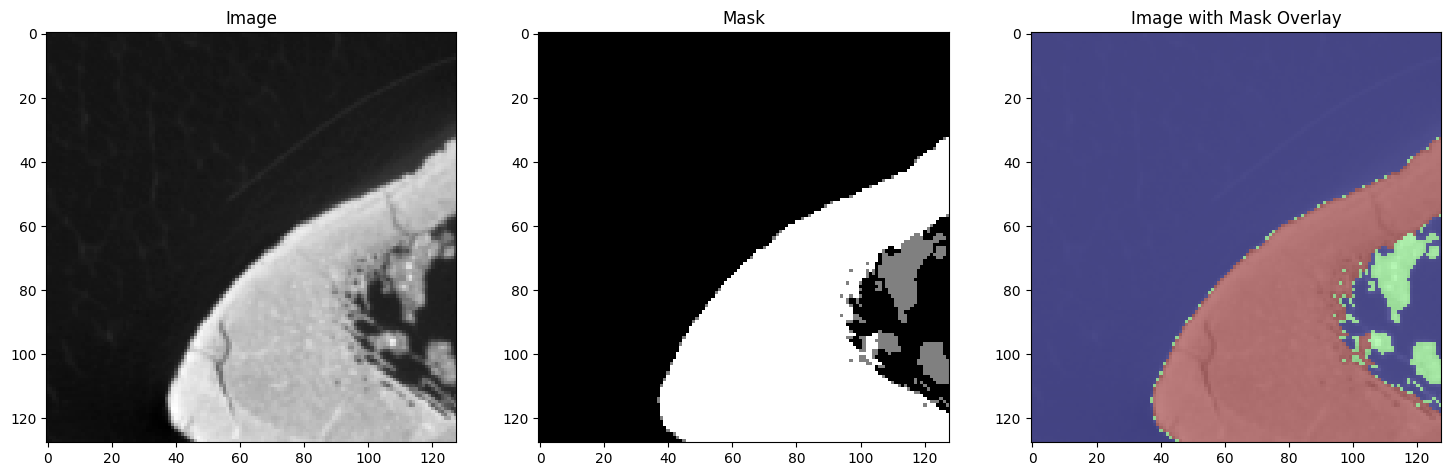

Image patch shape: torch.Size([1, 128, 128]), Mask patch shape: torch.Size([128, 128])


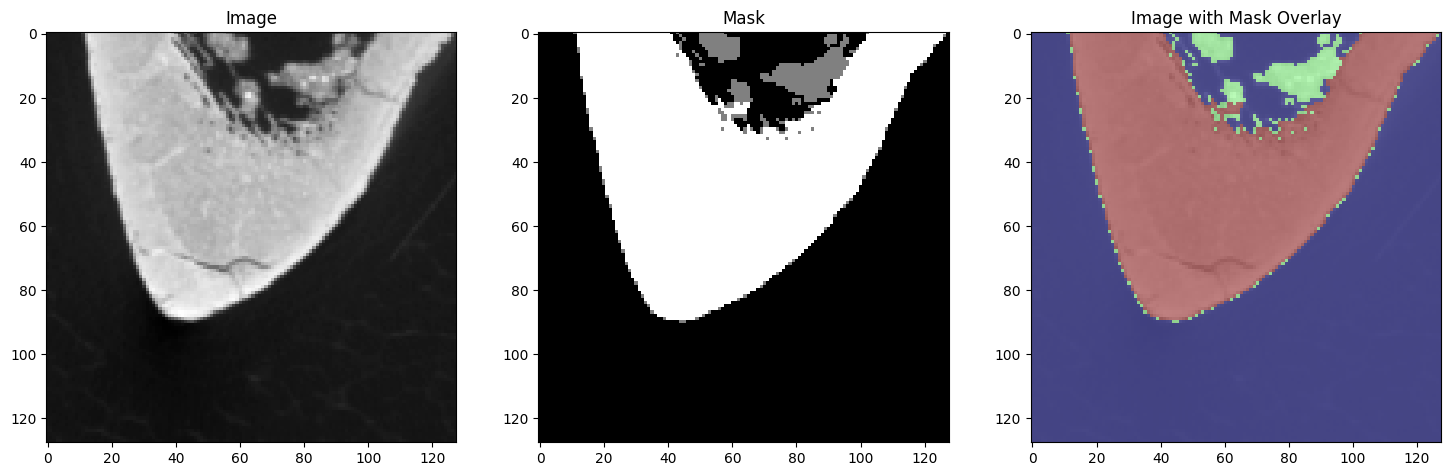

Image patch shape: torch.Size([1, 128, 128]), Mask patch shape: torch.Size([128, 128])


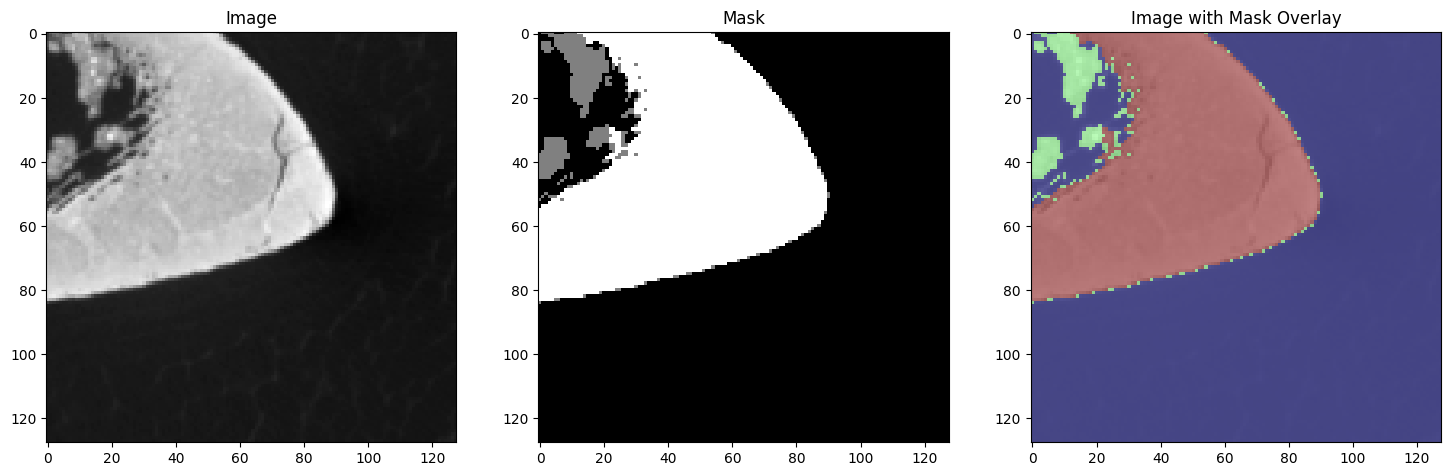

In [19]:
# Visual inspection
def visualize_patch(dataset, idx):
    sample = dataset[idx]
    image = sample['image']
    mask = sample['mask']

    # Debugging: Check that image and mask have the same dimensions
    assert image.shape[-2:] == mask.shape, f"Size mismatch: image shape {image.shape} vs mask shape {mask.shape}"
    print(f"Image patch shape: {image.shape}, Mask patch shape: {mask.shape}")

    plt.figure(figsize=(18, 6))

    # Adjust visualization for the image
    plt.subplot(1, 3, 1)
    plt.title("Image")
    if image.ndim == 2:  # Grayscale image
        plt.imshow(image, cmap='gray')
    elif image.ndim == 3:  # Multichannel image
        if image.shape[0] == 1:  # Single channel but 3D (like [1, H, W])
            plt.imshow(image[0], cmap='gray')
        else:  # RGB or other multi-channel format
            plt.imshow(image.permute(1, 2, 0))

    # Visualize the mask
    plt.subplot(1, 3, 2)
    plt.title("Mask")
    plt.imshow(mask, cmap='gray')

    # Overlay mask on image
    plt.subplot(1, 3, 3)
    plt.title("Image with Mask Overlay")
    if image.ndim == 3 and image.shape[0] == 1:
        image = image[0]  # Convert to 2D for display
    plt.imshow(image, cmap='gray', alpha=0.5)
    plt.imshow(mask, cmap='jet', alpha=0.5)

    plt.show()

# Convert filtered patches back to DataFrame (if needed)
filtered_train_patches_df = pd.DataFrame(filtered_train_patches, columns=["filename", "top", "left", "height", "width"])
filtered_val_patches_df = pd.DataFrame(filtered_val_patches, columns=["filename", "top", "left", "height", "width"])

# Create the dataset and dataloaders for the full dataset
train_dataset = HDF52D(filtered_train_patches_df.values.tolist(), filtered_val_patches_df.values.tolist(), train_transform=train_transform, val_transform=val_transform)
train_data_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)  # num_workers=0 for debugging

# Visualize a few patches from the training dataset
for i in range(3):
    visualize_patch(train_dataset, i)

Image shape: (259, 271), Mask shape: (259, 271)


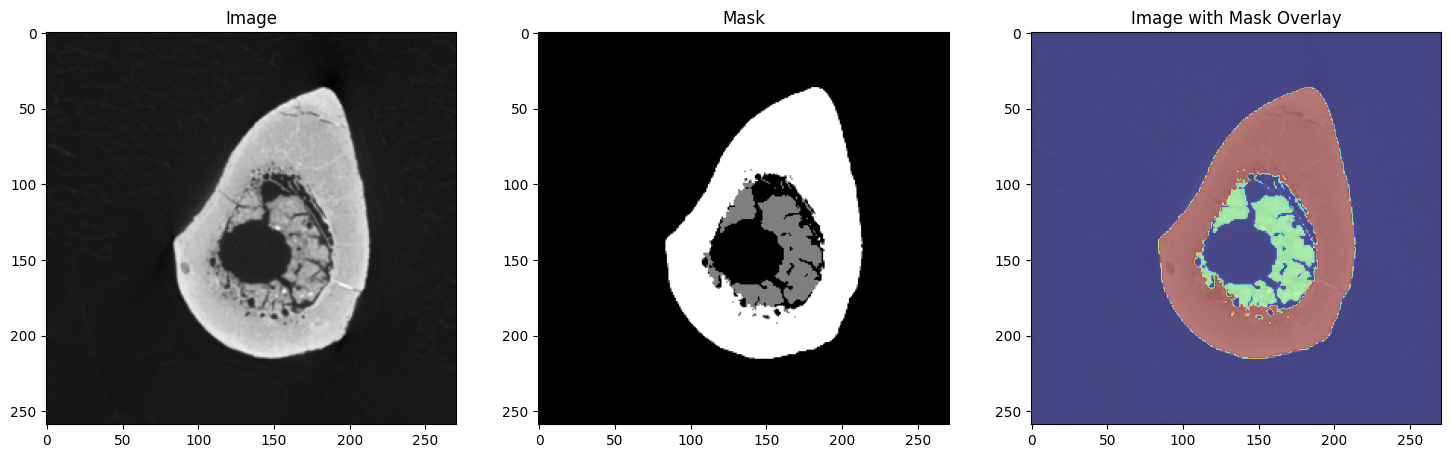

Image shape: (259, 271), Mask shape: (259, 271)


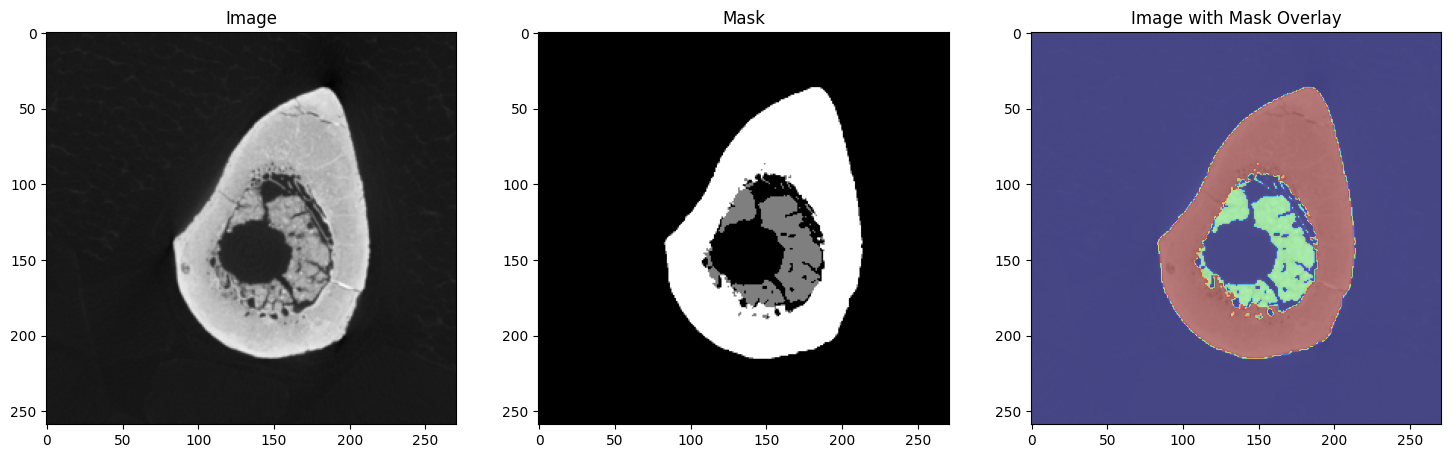

Image shape: (259, 271), Mask shape: (259, 271)


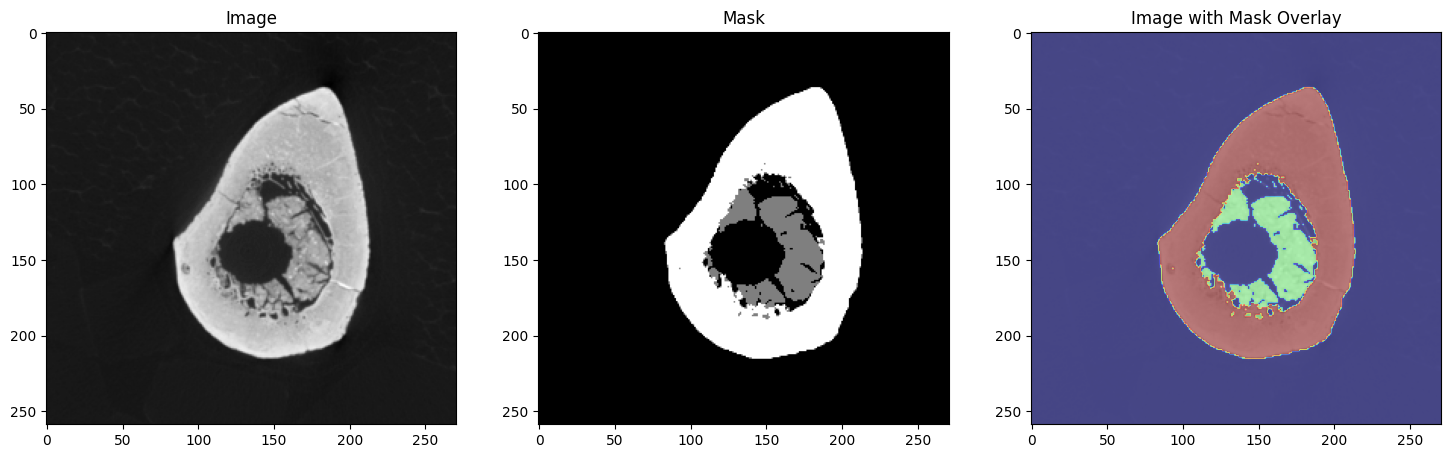

In [20]:
def visualize_image_and_mask(image_list, mask_list, idx):
    image_name = list(image_list.keys())[idx]
    image = image_list[image_name]
    mask = mask_list[image_name]

    # Debugging: Check that image and mask have the same dimensions
    assert image.shape[:2] == mask.shape[:2], f"Size mismatch: image shape {image.shape} vs mask shape {mask.shape}"
    print(f"Image shape: {image.shape}, Mask shape: {mask.shape}")

    plt.figure(figsize=(18, 6))

    # Adjust visualization for the image
    plt.subplot(1, 3, 1)
    plt.title("Image")
    if image.ndim == 2:  # Grayscale image
        plt.imshow(image, cmap='gray')
    elif image.ndim == 3:  # Multichannel image
        if image.shape[2] == 1:  # Single channel but 3D (like [H, W, 1])
            plt.imshow(image[:, :, 0], cmap='gray')
        else:  # RGB or other multi-channel format
            plt.imshow(image)

    # Visualize the mask
    plt.subplot(1, 3, 2)
    plt.title("Mask")
    plt.imshow(mask, cmap='gray')

    # Overlay mask on image
    plt.subplot(1, 3, 3)
    plt.title("Image with Mask Overlay")
    if image.ndim == 3 and image.shape[2] == 1:
        image = image[:, :, 0]  # Convert to 2D for display
    plt.imshow(image, cmap='gray', alpha=0.5)
    plt.imshow(mask, cmap='jet', alpha=0.5)

    plt.show()


# Visualize a few full images and masks from the dataset
for i in range(3):
    visualize_image_and_mask(input_list, label_list, i)


In [21]:
net = UNet_Light_RDN(n_channels=n_channel, n_classes=class_num, dropout_rate=dropout_rate)
net.to(device)

# Log the model
mlflow.pytorch.log_model(net, "model")

c:\Users\n.vanderesse\AppData\Local\ia-sereos_env\lib\site-packages\_distutils_hack\__init__.py:33: UserWarning: Setuptools is replacing distutils.
  warnings.warn("Setuptools is replacing distutils.")


In [22]:
optimizer = Adam(net.parameters(),
                      lr=float(learning_rate),
                      eps=float(epsilon),
                      betas=(0.9, 0.999),
                      weight_decay=weight_decay)

#learning rate schedule
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=period_size, gamma=0.1)

# Journalisation des hyperparamètres de l'optimiseur
mlflow.log_param("optimizer", "Adam")
mlflow.log_param("betas", (0.9, 0.999))


(0.9, 0.999)

# Training loop

In [23]:
# Initialize lists to collect metrics from nested runs
nested_metrics = {
    'train_loss': [],
    'val_accuracy': [],
    'dice_overlap_class_0': [],
    'dice_overlap_class_1': [],
    'dice_overlap_class_2': []
}

# Function to visualize images on TensorBoard
def visualize_images(writer, net, image, mask, device, nb_ite, last_batches, epoch):
    with torch.no_grad():
        pred2 = net(image)
    m2 = mask.argmax(1)
    m2 = m2.cpu().squeeze().data.numpy()
    pred2 = pred2.argmax(1)
    pred2 = pred2.cpu().squeeze().data.numpy()
    color_dict = [[0.0], [128.0/255.0], [1]]
    pred_img = torch.empty_like(image).copy_(image)
    mask_img = torch.empty_like(image).copy_(image)
    pred_img = pred_img.to(device)
    mask_img = mask_img.to(device)

    for i in range(len(pred_img)):
        for j in range(len(pred_img[i][0])):
            for k in range(len(pred_img[i][0][j])):
                pred_img[i][0][j][k] = color_dict[pred2[i][j][k]][0]
                mask_img[i][0][j][k] = color_dict[m2[i][j][k]][0]

    writer.add_image('input_image', torchvision.utils.make_grid(image), nb_ite + last_batches)
    writer.add_image('prediction_image', torchvision.utils.make_grid(pred_img), nb_ite + last_batches)
    writer.add_image('mask_image', torchvision.utils.make_grid(mask_img), nb_ite + last_batches)

# rdn_train train the model for one iteration
# Input : 
# net: The neural network model being trained.
# optimizer: The optimizer used for updating the model's parameters.
# data_loader: DataLoader providing batches of training data.
# epoch: Current epoch number (optional).
# total_epoch: Total number of epochs (optional).
# tensorboard_plot: Boolean flag for visualizing results on TensorBoard (default is False).
#
# Output :
# returns the total number of iterations processed for this epoch (nb_ite + last_batches)
def rdn_train(net, optimizer, data_loader, epoch=None, total_epoch=None, tensorboard_plot=False, nb_ite=0):
    max_batches1 = len(data_loader.dataset) // data_loader.batch_size + (1 if (len(data_loader.dataset) % data_loader.batch_size) != 0 else 0)
    epoch_print = f'Epoch:{epoch + 1}/{total_epoch}' if epoch is not None and total_epoch is not None else 'Epoch:'
    last_batches = 0.0
    loss1_sum = 0.0
    loss2_sum = 0.0
    ite = 0

    with tqdm(total=len(data_loader.dataset), desc=epoch_print, unit=' batches') as pbar:
        for i_batches, sample_batched in enumerate(data_loader):
            last_batches = i_batches
            mask = sample_batched['mask']
            image = sample_batched['image']

            mask = mask.to(device).long()
            image = image.to(device)

            pred = net(image)

            loss1 = torch.Tensor(0)
            mask = create_one_hot(mask)

            CE_loss = nn.CrossEntropyLoss()
            loss2 = CE_loss(pred, mask)
            loss2.to(device)

            nested_metrics['train_loss'].append(loss2.item())

            optimizer.zero_grad()
            loss2.backward()
            optimizer.step()

            if tensorboard_plot and epoch == 0 and ite == 0:
                writer.add_graph(net, image)
            if tensorboard_plot and (ite % (max_batches1 // 3) == 0):
                visualize_images(writer, net, image, mask, device, ite, last_batches, epoch)

            pbar.update(mask.shape[0])
            pbar.set_postfix(loss=loss2.cpu().data.numpy(), loss1=loss1.cpu().data.numpy(), loss2=loss2.cpu().data.numpy())
            loss1_sum += loss1.cpu().data.numpy()
            loss2_sum += loss2.cpu().data.numpy()
            ite += 1

        avg_loss2 = loss2_sum / (last_batches + 1)
        writer.add_scalar('avg_train_loss2', avg_loss2)
        print(f'\nAverage, loss2: {avg_loss2:.6f}.')

        mlflow.log_metric("avg_train_loss2", avg_loss2, step=epoch)

    return nb_ite + last_batches



# rdn_val test the accuracy of the model for the current epoch
# Input :
# net: The neural network model.
# data_set: The dataset for validation.
# i_epoch: Current epoch number (optional).
# class_num: Number of classes in the dataset (default is 3).
#
# Output :
# returns the accuracy (criterion_value) and class-wise dice overlap results.
def rdn_val(net, data_loader, i_epoch=None, class_num=3):
    dice_overlap = DiceOverlap(class_num)

    origin_is_train_mode = net.training
    if origin_is_train_mode:
        net.eval()

    criterion_value_sum = 0.0
    dice_overlap_results = np.zeros(class_num)

    for i_batches, sample_batched in enumerate(data_loader):
        mask = sample_batched['mask']
        image = sample_batched['image']

        mask = mask.to(device)
        image = image.to(device)

        with torch.no_grad():
            if image.shape == (1, 1, 64, 64):  # Adjust to match your input size
                pred = net(image)
                acc_value = Accuracy()(pred, mask.long()).cpu().data.numpy()
                criterion_value_sum += acc_value

                if dice_overlap is not None:
                    dice_results = dice_overlap(pred, mask.long())
                    dice_overlap_results += dice_results

                print(f"Validation Batch {i_batches + 1}: Accuracy: {acc_value}")
                print(f"Prediction shape: {pred.shape}, Mask shape: {mask.shape}")
                print(f"Dice Results: {dice_results}")

    criterion_value = criterion_value_sum / len(data_loader.dataset)
    dice_overlap_results = dice_overlap_results / len(data_loader.dataset)

    for i in range(len(dice_overlap_results)):
        print(f'Class: {i}, Dice Overlap: {dice_overlap_results[i]:.6f}')

    if origin_is_train_mode:
        net.train()

    mlflow.log_metric("val_accuracy", criterion_value, step=i_epoch)
    for i in range(len(dice_overlap_results)):
        mlflow.log_metric(f"dice_overlap_class_{i}", dice_overlap_results[i], step=i_epoch)

    if i_epoch is not None:
        print(f"Epoch: {i_epoch + 1}, Accuracy Value: {criterion_value:.6f}")
        writer = SummaryWriter(runs_dir)
        writer.add_scalars('Dice Overlap', {'Air': dice_overlap_results[0], 'Dirt': dice_overlap_results[1], 'Bone': dice_overlap_results[2]}, i_epoch)
        writer.close()
    return criterion_value, dice_overlap_results




class DiceOverlap():
    def __init__(self, class_num):
        self.len = class_num

    def __call__(self, input, target):
        input = F.sigmoid(input)
        input = torch.max(input, 1)[1]

        dice = []

        for i in range(self.len):
            sub_target = torch.zeros(target.shape).cuda()
            sub_target[target == i] = 1
            sub_input = torch.zeros(input.shape).cuda()
            sub_input[input == i] = 1

            tp_idx = target == i

            eps = 0.0001
            tp = torch.sum(sub_input[tp_idx] == sub_target[tp_idx])
            fn = torch.sum(sub_input != sub_target)
            tp = tp.float()
            fn = fn.float()
            
            print(f"Class {i}: tp={tp}, fn={fn}, tp_idx sum={torch.sum(tp_idx)}, sub_input sum={torch.sum(sub_input)}, sub_target sum={torch.sum(sub_target)}")

            result = (2 * tp + eps) / (2 * tp + fn + eps)
            dice.append(result.cpu().data.numpy())

        return np.asarray(dice)


    
class Accuracy():
    def __call__(self, input, target, **kwargs):
        input = torch.max(input, 1)[1]
        size = 1
        for i in range(len(input.shape)):
            size = size * input.shape[i]
        return torch.sum(input == target).float() / size


In [24]:


# Initialize lists to collect metrics from nested runs
nested_metrics = {
    'train_loss': [],
    'val_accuracy': [],
    'dice_overlap_class_0': [],
    'dice_overlap_class_1': [],
    'dice_overlap_class_2': []
}



# Convert filtered patches back to DataFrame
filtered_train_patches_df = pd.DataFrame(filtered_train_patches, columns=["filename", "top", "left", "height", "width"])
filtered_val_patches_df = pd.DataFrame(filtered_val_patches, columns=["filename", "top", "left", "height", "width"])

# Create the dataset and dataloaders for the full dataset
train_dataset = HDF52D(filtered_train_patches_df.values.tolist(), filtered_val_patches_df.values.tolist(), train_transform=train_transform, val_transform=val_transform)
train_data_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)  # num_workers=0 for debugging

# Debug the full DataLoader before starting training
print("Debugging the full DataLoader...")
debug_data_loader(train_data_loader)
print("Full DataLoader debug complete.")

# Training loop
epoch_count = 0
print(f"Epoch progress:")
print(f"Progress training {epochs_num} epochs...")
total_timer = timer()
iteration = 0
nb_ite = 0

for i_epoch in range(epochs_num):
    nested_runs_dir = os.path.join(runs_dir, f"epoch_{i_epoch + 1}")
    writer = SummaryWriter(nested_runs_dir)
    with mlflow.start_run(nested=True, run_name=f"epoch_{i_epoch + 1}"):
        print(f"Epoch {epoch_count + 1} of {epochs_num}")

        # Dynamic air rate based on epoch
        air_rate = 0.1 if i_epoch < period_size else 0.2 if i_epoch < 2 * period_size else 0.4 if i_epoch < 3 * period_size else 0.5
        mlflow.log_param("air_rate", air_rate)

        print(f"Learning rate {optimizer.param_groups[0]['lr']:.6f}")
        nb_ite = rdn_train(net, optimizer, train_data_loader, epoch=i_epoch, total_epoch=epochs_num, tensorboard_plot=True, nb_ite=nb_ite)

        # Switch dataset to validation mode
        train_dataset.val()
        val_data_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

        # Validating
        val_accuracy, dice_overlap_results = rdn_val(net, val_data_loader, i_epoch=i_epoch, class_num=class_num)

        class_val = pd.DataFrame(dice_overlap_results)
        class_val.columns = ["Class Dice overlap"]
        print(class_val)
        epoch_count += 1
        iteration = np.floor((100 * epoch_count) / int(epochs_num))

# Save model
torch.save(net.state_dict(), "RDN.pth")

# Aggregate and log metrics from nested runs to the main run
avg_train_loss = np.mean(nested_metrics['train_loss'])
avg_val_accuracy = np.mean(nested_metrics['val_accuracy'])
avg_dice_overlap_class_0 = np.mean(nested_metrics['dice_overlap_class_0'])
avg_dice_overlap_class_1 = np.mean(nested_metrics['dice_overlap_class_1'])
avg_dice_overlap_class_2 = np.mean(nested_metrics['dice_overlap_class_2'])

mlflow.log_metric("avg_train_loss", avg_train_loss)
mlflow.log_metric("avg_val_accuracy", avg_val_accuracy)
mlflow.log_metric("avg_dice_overlap_class_0", avg_dice_overlap_class_0)
mlflow.log_metric("avg_dice_overlap_class_1", avg_dice_overlap_class_1)
mlflow.log_metric("avg_dice_overlap_class_2", avg_dice_overlap_class_2)

# End MLflow run
mlflow.end_run()
# Close the TensorBoard writer
writer.close()



Debugging the full DataLoader...
Batch 1 loaded successfully
Batch 1 - Image shape: torch.Size([32, 1, 128, 128]), Mask shape: torch.Size([32, 128, 128])
Batch 2 loaded successfully
Batch 2 - Image shape: torch.Size([32, 1, 128, 128]), Mask shape: torch.Size([32, 128, 128])
Batch 3 loaded successfully
Batch 3 - Image shape: torch.Size([32, 1, 128, 128]), Mask shape: torch.Size([32, 128, 128])
Time taken to load 3 batches: 0.10976791381835938 seconds
Full DataLoader debug complete.
Epoch progress:
Progress training 8 epochs...
Epoch 1 of 8
Learning rate 0.001000


Epoch:1/8:   0%|          | 0/576 [00:00<?, ? batches/s]C:\Users\n.vanderesse\AppData\Local\Temp\ipykernel_56832\966783669.py:52: TracerWarning: torch.tensor results are registered as constants in the trace. You can safely ignore this warning if you use this function to create tensors out of constant variables that would be the same every time you call this function. In any other case, this might cause the trace to be incorrect.
  diffY = torch.tensor([x2.size()[2] - x1.size()[2]])
C:\Users\n.vanderesse\AppData\Local\Temp\ipykernel_56832\966783669.py:53: TracerWarning: torch.tensor results are registered as constants in the trace. You can safely ignore this warning if you use this function to create tensors out of constant variables that would be the same every time you call this function. In any other case, this might cause the trace to be incorrect.
  diffX = torch.tensor([x2.size()[3] - x1.size()[3]])
Epoch:1/8:   0%|          | 0/576 [00:25<?, ? batches/s]


KeyboardInterrupt: 

In [ ]:
def inspect_predictions(dataloader, model, device):
    model.eval()
    with torch.no_grad():
        for i, sample in enumerate(dataloader):
            image = sample['image'].to(device)
            mask = sample['mask'].to(device)

            # Make predictions
            output = model(image)
            preds = output.argmax(dim=1)

            # Move predictions to CPU and convert to numpy array
            preds = preds.cpu().numpy()

            # Inspect unique values in the predictions
            unique_values = np.unique(preds)
            print(f"Unique values in predictions for batch {i}: {unique_values}")

            if i == 0:  # Inspect only the first batch for now
                break

# Example usage with your validation DataLoader
inspect_predictions(val_data_loader, net, device)


In [ ]:
def visualize_last_batch(dataloader, model, device):
    model.eval()
    with torch.no_grad():
        for i, sample in enumerate(dataloader):
            image = sample['image'].to(device)
            mask = sample['mask'].to(device)

            # Store the last batch
            last_image_batch = image
            last_mask_batch = mask

        # Make predictions on the last batch
        output = model(last_image_batch)
        preds = output.argmax(dim=1)

        # Move predictions to CPU and convert to numpy array
        preds = preds.cpu().numpy()
        masks = last_mask_batch.cpu().numpy()

        # Inspect unique values in the predictions and masks
        unique_values_preds = np.unique(preds)
        unique_values_masks = np.unique(masks)
        print(f"Unique values in predictions: {unique_values_preds}")
        print(f"Unique values in ground truth masks: {unique_values_masks}")

        # Debugging: Check the shape of inputs and outputs
        print(f"Input batch shape: {last_image_batch.shape}")
        print(f"Mask batch shape: {last_mask_batch.shape}")
        print(f"Prediction batch shape: {preds.shape}")

        # Ensure the output dimensions match the input dimensions
        assert preds.shape[1:] == last_image_batch.shape[2:], (
            f"Output shape {preds.shape[1:]} does not match input shape {last_image_batch.shape[2:]}"
        )

        # Visualize the last batch
        batch_size = preds.shape[0]
        for idx in range(batch_size):
            plt.figure(figsize=(18, 6))

            # Original Image
            plt.subplot(1, 3, 1)
            plt.title("Original Image")
            image_np = last_image_batch[idx].cpu().numpy()
            if image_np.ndim == 2:  # Grayscale image
                plt.imshow(image_np, cmap='gray')
            elif image_np.ndim == 3 and image_np.shape[0] == 1:  # Single channel but 3D (like [1, H, W])
                plt.imshow(image_np[0], cmap='gray')
            elif image_np.ndim == 3:  # Multichannel image
                plt.imshow(np.transpose(image_np, (1, 2, 0)))

            # Ground Truth Mask
            plt.subplot(1, 3, 2)
            plt.title("Ground Truth Mask")
            plt.imshow(masks[idx], cmap='gray')

            # Predicted Mask
            plt.subplot(1, 3, 3)
            plt.title("Predicted Mask")
            plt.imshow(preds[idx], cmap='gray')

            plt.show()

# Example usage with your validation DataLoader
visualize_last_batch(val_data_loader, net, device)
